In [1]:
using Pkg
Pkg.activate("./", io=devnull)
using Evaluation
using StatsPlots
using DataFrames
using CSV
using LaTeXStrings

In [34]:
curr_dir = @__DIR__
exp_final_dir = joinpath(curr_dir, "..", "experiments", "experiments_final")

acas_name = "acas-0.05-120"
# mnist_name = "mnist-1.0-120"
# mnist_name = "mnist-global_4-5-1.0-600"
mnist_name = "mnist-global_4-5-adam_1_stepsize-1.0-600"

eval_acas_dir = joinpath(curr_dir, "eval_acas")
eval_mnist_dir = joinpath(curr_dir, "eval_mnist")

# mkdir(eval_acas_dir)
# mkdir(eval_mnist_dir)

results_file = "results.csv"
csv_title = ["net", "spec", "status", "runtime", "num_propagations", "num_input_splits", "num_neuron_splits", "initial_δ_bound", "final_δ_bound"]

heuristic_variants = ["DU"]

configs = ["LP"]
configs = mapreduce(c -> c * "-" .* heuristic_variants, vcat, configs)
configs = vcat(configs, "VeryDiff")
configs = mapreduce(c -> ["AP-"] .* c, vcat, configs)
configs = mapreduce(c -> c .* ["", "-CSB"], vcat, configs)
# configs = sort(configs, by=c->ifelse(c[1:3] == "AP-", c[4:end], c))
# configs = vcat("VeryDiff", configs)

configs_paths = Dict(c => joinpath(exp_final_dir, c) for c in configs)
acas_paths = Dict(c => joinpath(configs_paths[c], acas_name, results_file) for c in configs)
mnist_paths = Dict(c => joinpath(configs_paths[c], mnist_name, results_file) for c in configs)

println("...")

...


In [35]:
configs_names = Dict(c => replace(c, 
        r"\-*(Base|Input|DiffZono|DU)" => "",
        "AP-" => "",
        "DeepSplit" => "LP", 
        "VerticalSplitting" => "VS", 
        "ZonoContract" => "ZC"
    ) for c in configs
)

Dict{String, String} with 4 entries:
  "AP-VeryDiff"     => "VeryDiff"
  "AP-LP-DU-CSB"    => "LP-CSB"
  "AP-LP-DU"        => "LP"
  "AP-VeryDiff-CSB" => "VeryDiff-CSB"

In [49]:
get_data = path -> CSV.read(path, DataFrame, header=csv_title, delim=", ")
get_config_data = path -> get_data(path)

mnist_dfs = DataFrame()
mnist_dfs[!, :config] = configs
mnist_dfs[!, :df] = map(c -> get_config_data(mnist_paths[c]), mnist_dfs.config)

sort!(mnist_dfs, [order(:config, by=c->ifelse(occursin("VeryDiff", c), "A" * c, c))])

for config in eachrow(mnist_dfs)
    config.df[!, :δ_bound] = δ_bound_improvement(config.df, 1.0)
end

In [5]:
p = plot(dpi=600, widen=true, legend=false, label=false; layout=grid(2, 2), size=(600, 450))

plot!(guidefontsize=8, tickfontsize=4, titlefontsize=5, legendfontsize=3)
plot!(plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)

combinations = [(2, 1), (4, 3), (6, 5), (8, 7)]

for (n, (i, j)) in enumerate(combinations)
    df₁, df₂ = mnist_dfs[i, :], mnist_dfs[j, :]

    xlabel!(configs_names[df₁.config], subplot=n)
    ylabel!(configs_names[df₂.config], subplot=n)

    common_unverified = df₁.df.status .== "UNKNOWN" .== df₂.df.status
    common_verified = df₁.df.status .!= "UNKNOWN" .!= df₂.df.status
    df_unverified₁ = df₁.df[common_unverified, :]
    df_unverified₂ = df₂.df[common_unverified, :]
    df_verified₁ = df₁.df[common_verified, :]
    df_verified₂ = df₂.df[common_verified, :]
    
    @assert all(df_unverified₁.spec .== df_unverified₂.spec)
    @assert all(df_verified₁.status .== df_verified₂.status)

    y₁ = df_unverified₁.num_propagations
    y₂ = df_unverified₂.num_propagations
    # y₁ = df_verified₁.num_propagations
    # y₂ = df_verified₂.num_propagations

    N = max(maximum(y₁), maximum(y₂))
    
    plot!(p, title="Number of Porpagations (Commonly Unverified)", titlefontsize=5, subplot=n)
    # plot!(p, title="Number of Porpagations (Commonly Verified)", titlefontsize=5, subplot=n)
    scatter!(p, y₁, y₂, markersize=2.0, subplot=n)
    plot!(p, range(0, N), range(0, N), c=3, z_order=1, subplot=n)
end

savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-unverified-num_propagations.png"))
savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-unverified-num_propagations.pdf"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-verified-num_propagations.png"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-verified-num_propagations.pdf"))

p

BoundsError: BoundsError: attempt to access 3×2 DataFrame at index [4, :]

In [6]:
i, j = 3, 4
df₁, df₂ = mnist_dfs[i, :].df, mnist_dfs[j, :].df
common = df₁.status .== df₂.status
display(collect(zip(df₁.spec[.!common], df₂.spec[.!common])))
display(collect(zip(df₁.status[.!common], df₂.status[.!common])))
display(collect(zip(df₁.num_propagations[.!common], df₂.num_propagations[.!common])))
display(collect(zip(df₁.runtime[.!common] ./ 1e9, df₂.runtime[.!common] ./ 1e9)))

BoundsError: BoundsError: attempt to access 3×2 DataFrame at index [4, :]

[88, 88, 92, 118]


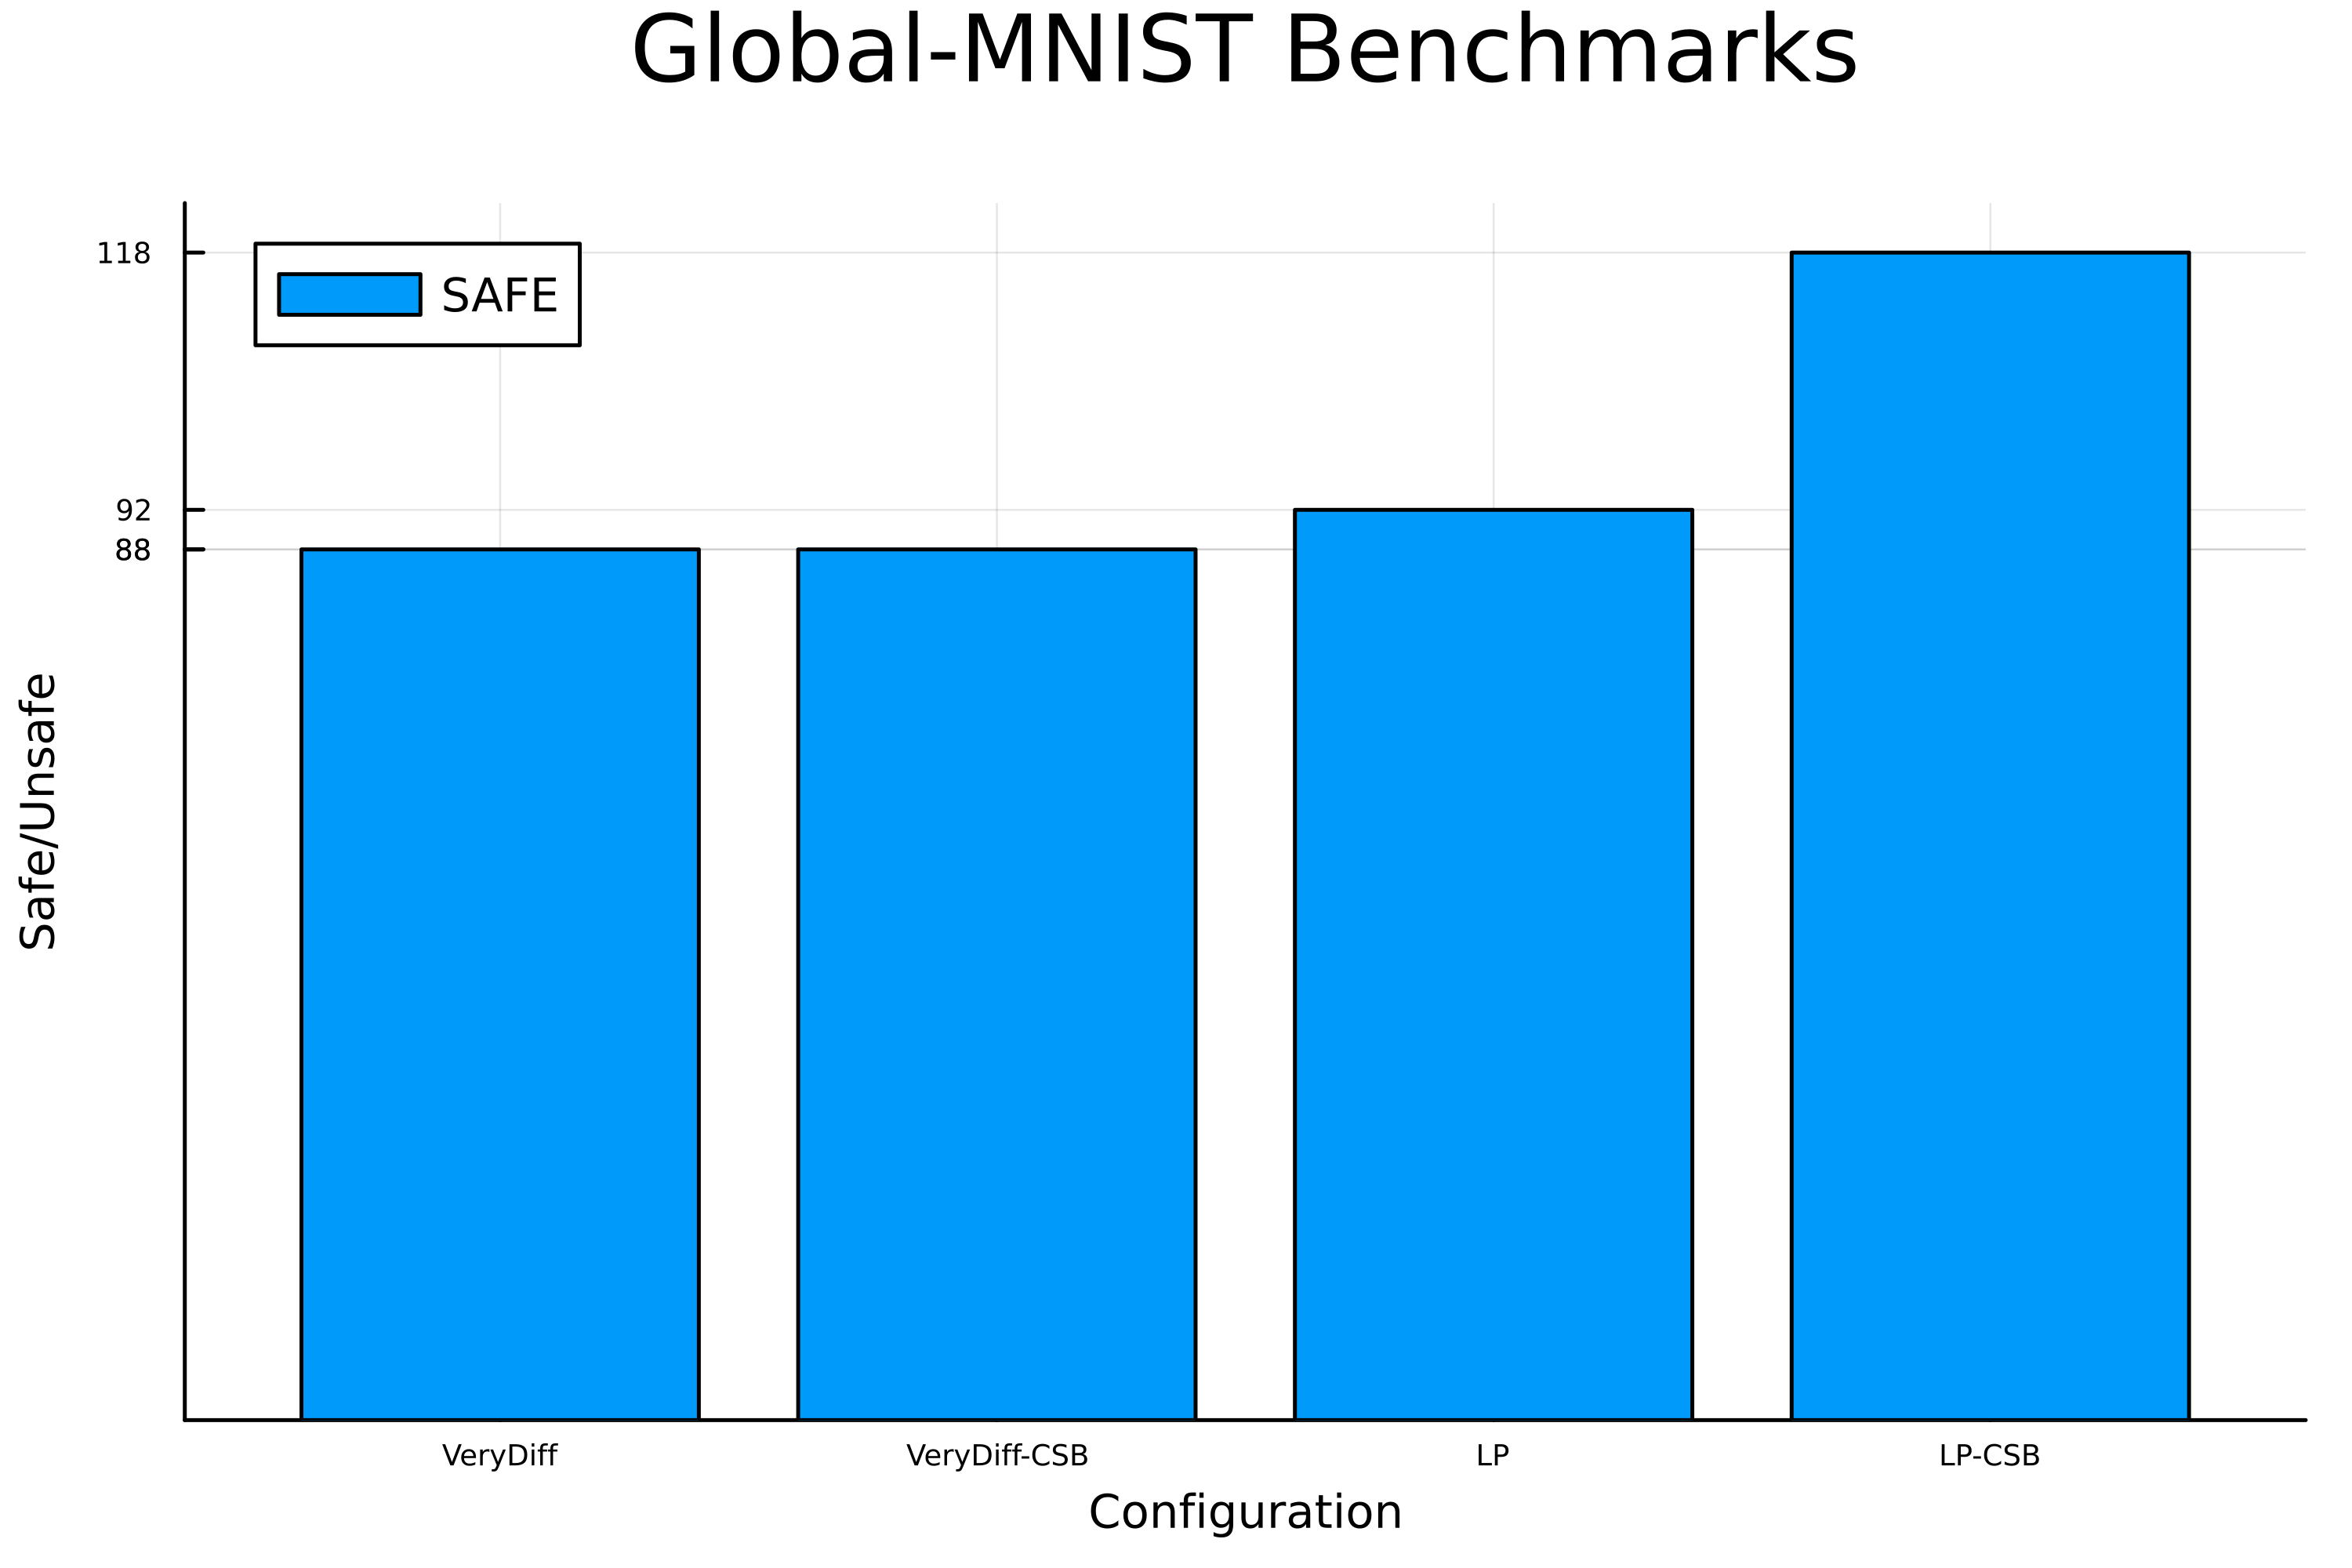

In [50]:
p = plot(dpi=500, widen=true)
plot!(plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(legendfontsize=8, guidefontsize=8, tickfontsize=5, xrotation=0)

xlabel!("Configuration")
ylabel!("Safe/Unsafe")

dfs = DataFrame[]
for config in eachrow(mnist_dfs)
    df = config.df
    df = df[df.status .!= "UNKNOWN", :]
    df[!, :group] .= df.status
    df = combine(groupby(df, :group), nrow => :count)
    df[!, :config] .= config.config
    push!(dfs, df)
end

df = vcat(dfs...)
# sort!(df, )
@df df groupedbar!(:count, group=:group, bar_position=:stack)
@df df xticks!(1:length(:config), map(c -> configs_names[c], :config))
@df df ylims!(0, maximum(:count) + 5)
@df df yticks!(:count)
@df df println(:count)

savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-hist.pdf"))
savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-hist.png"))

p

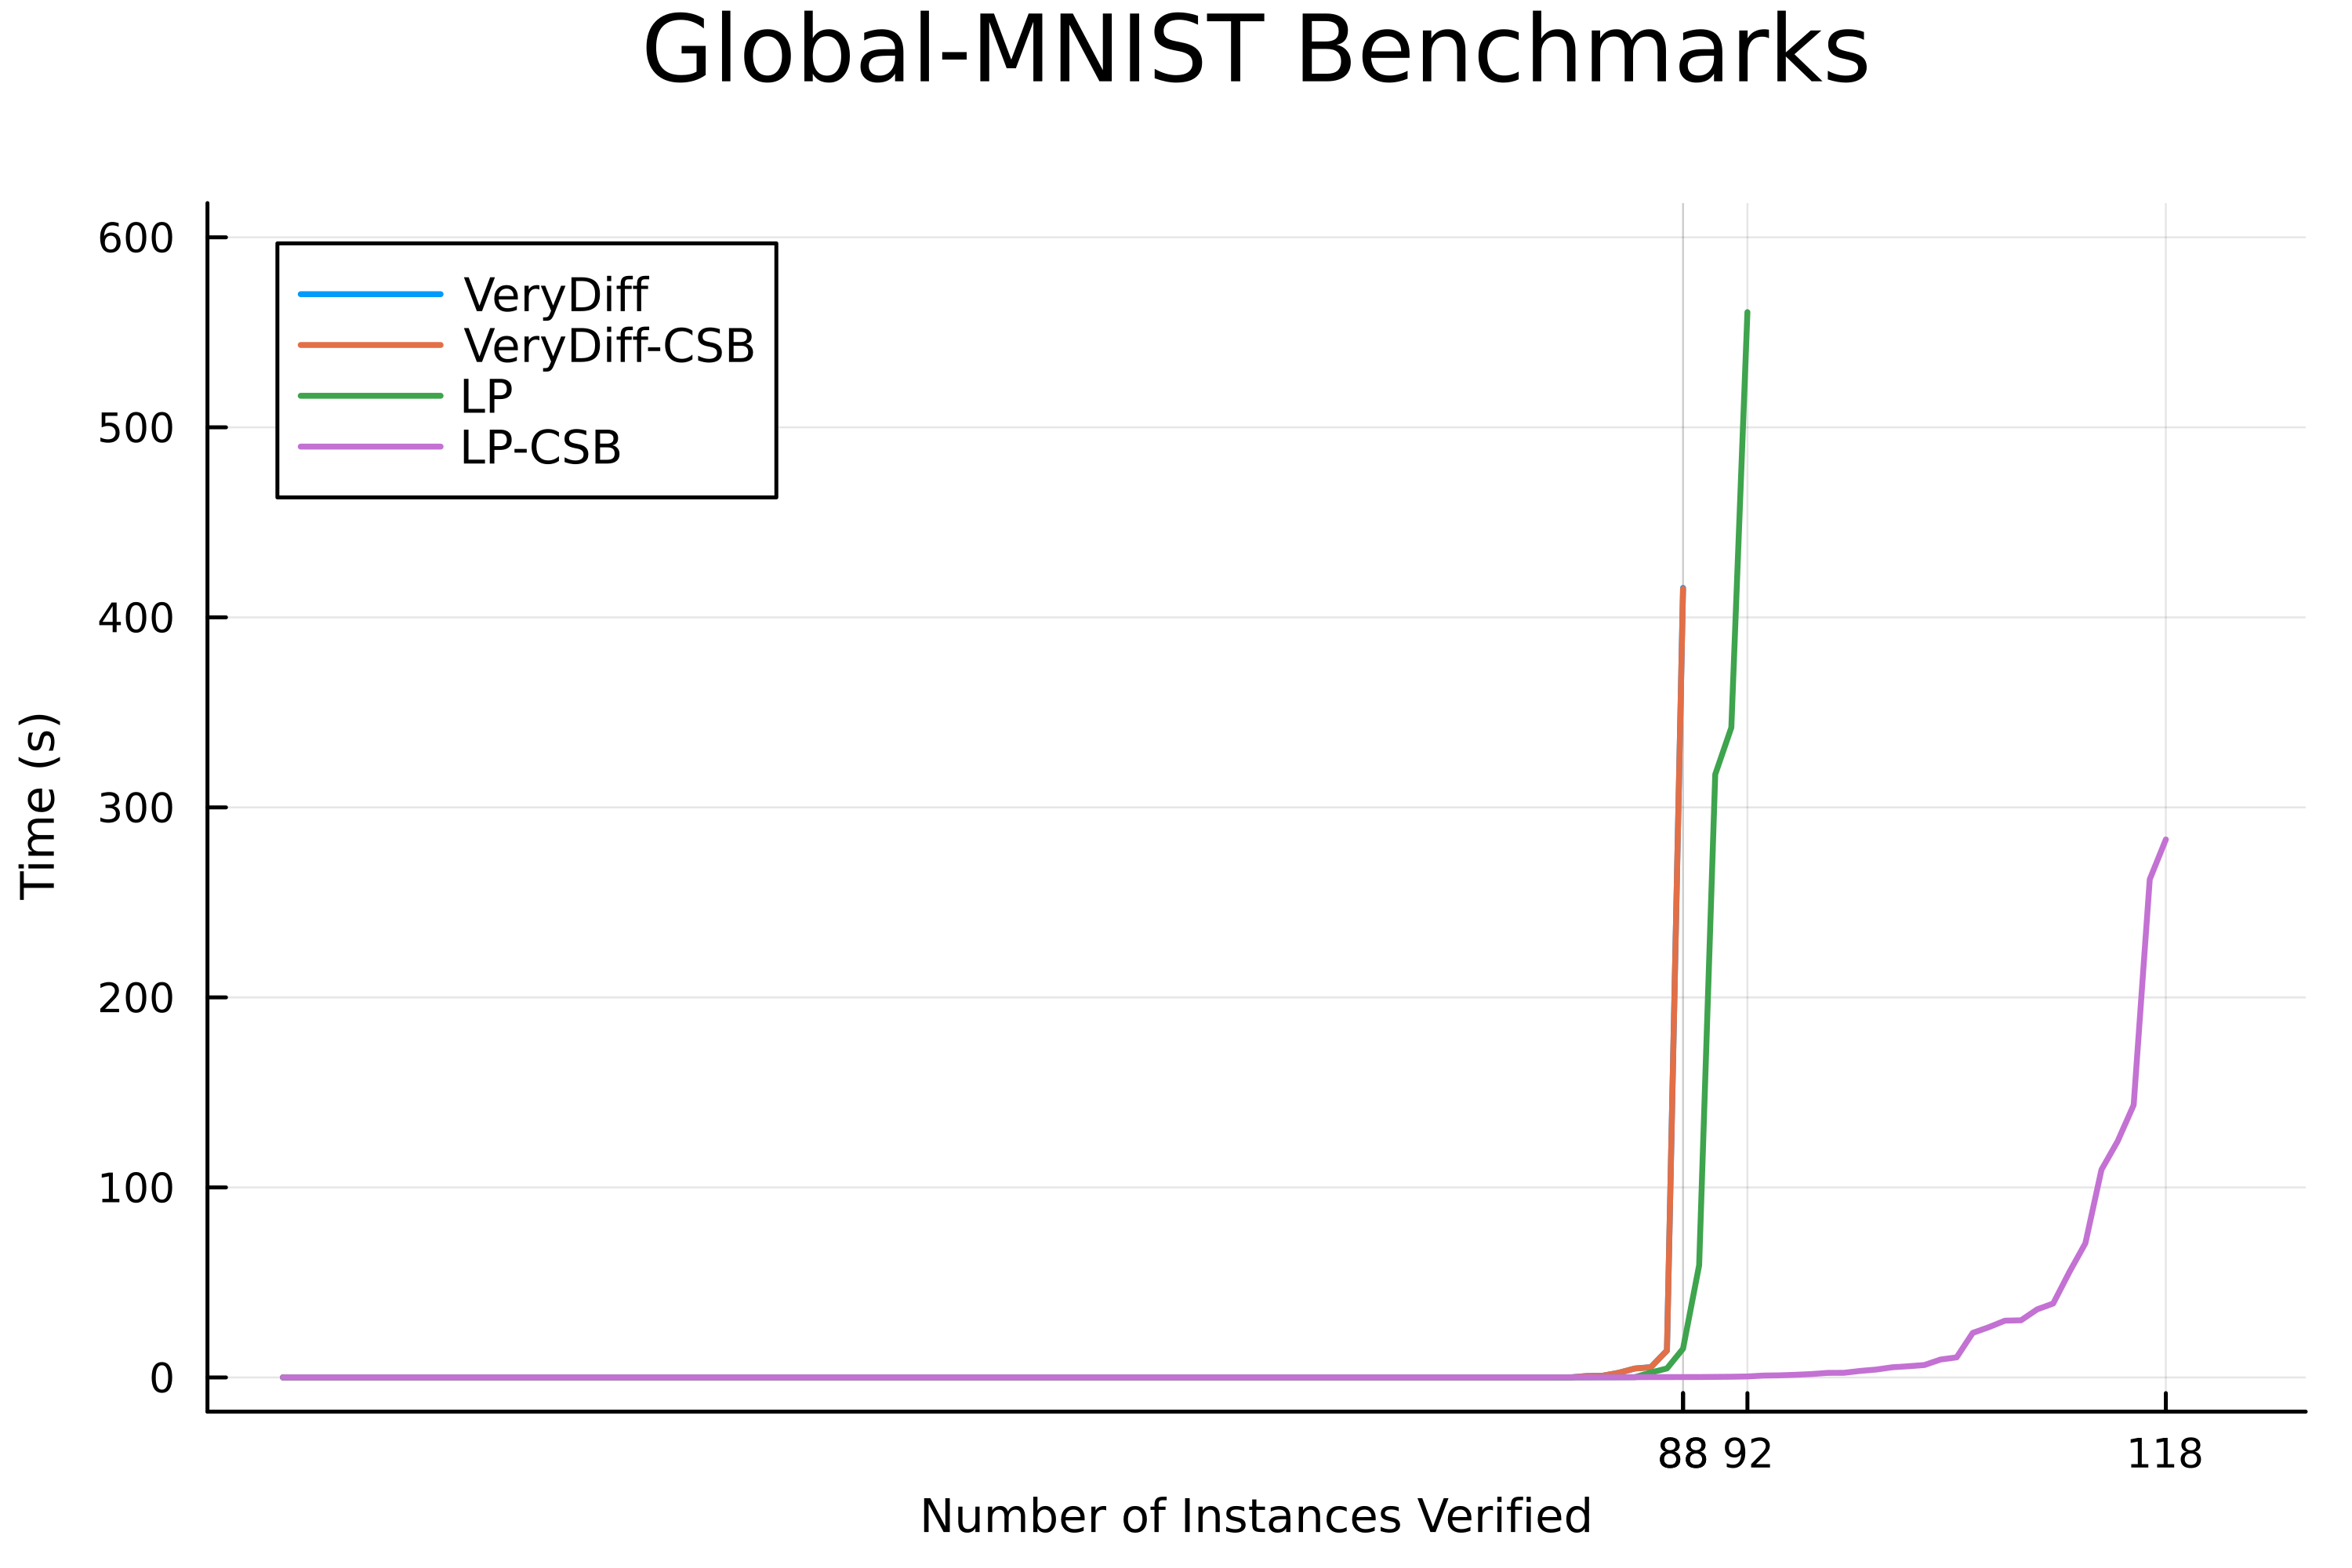

In [53]:
p = plot(dpi=500, widen=true, legend=:topleft)
plot!(plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(legendfontsize=8, guidefontsize=8, tickfontsize=7, xrotation=0)

xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

n = 4

for config in eachrow(mnist_dfs[1:n, :])
    df = config.df
    df = df[df.status .!= "UNKNOWN", :]
    df = sort(df, [order(:runtime)])
    df[!, :runtime] ./= 1e9
    @df df plot!(:runtime, lw=1.5, label=configs_names[config.config])
end

# plot!([], label=" ", lc=:transparent)
# plot!([], label=" ", lc=:transparent)

num_solved = [count(config.df.status .!= "UNKNOWN") for config in eachrow(mnist_dfs)]

x_max = maximum(num_solved)
# y_max = maximum(config.df[!, :runtime] for config in eachrow(mnist_dfs))

xlims!(0, x_max + 5)
ylims!(0, 600)
xticks!(num_solved[1:n])

# savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-$n.pdf"))
# savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-$n.png"))
savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name.pdf"))
savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name.png"))

p

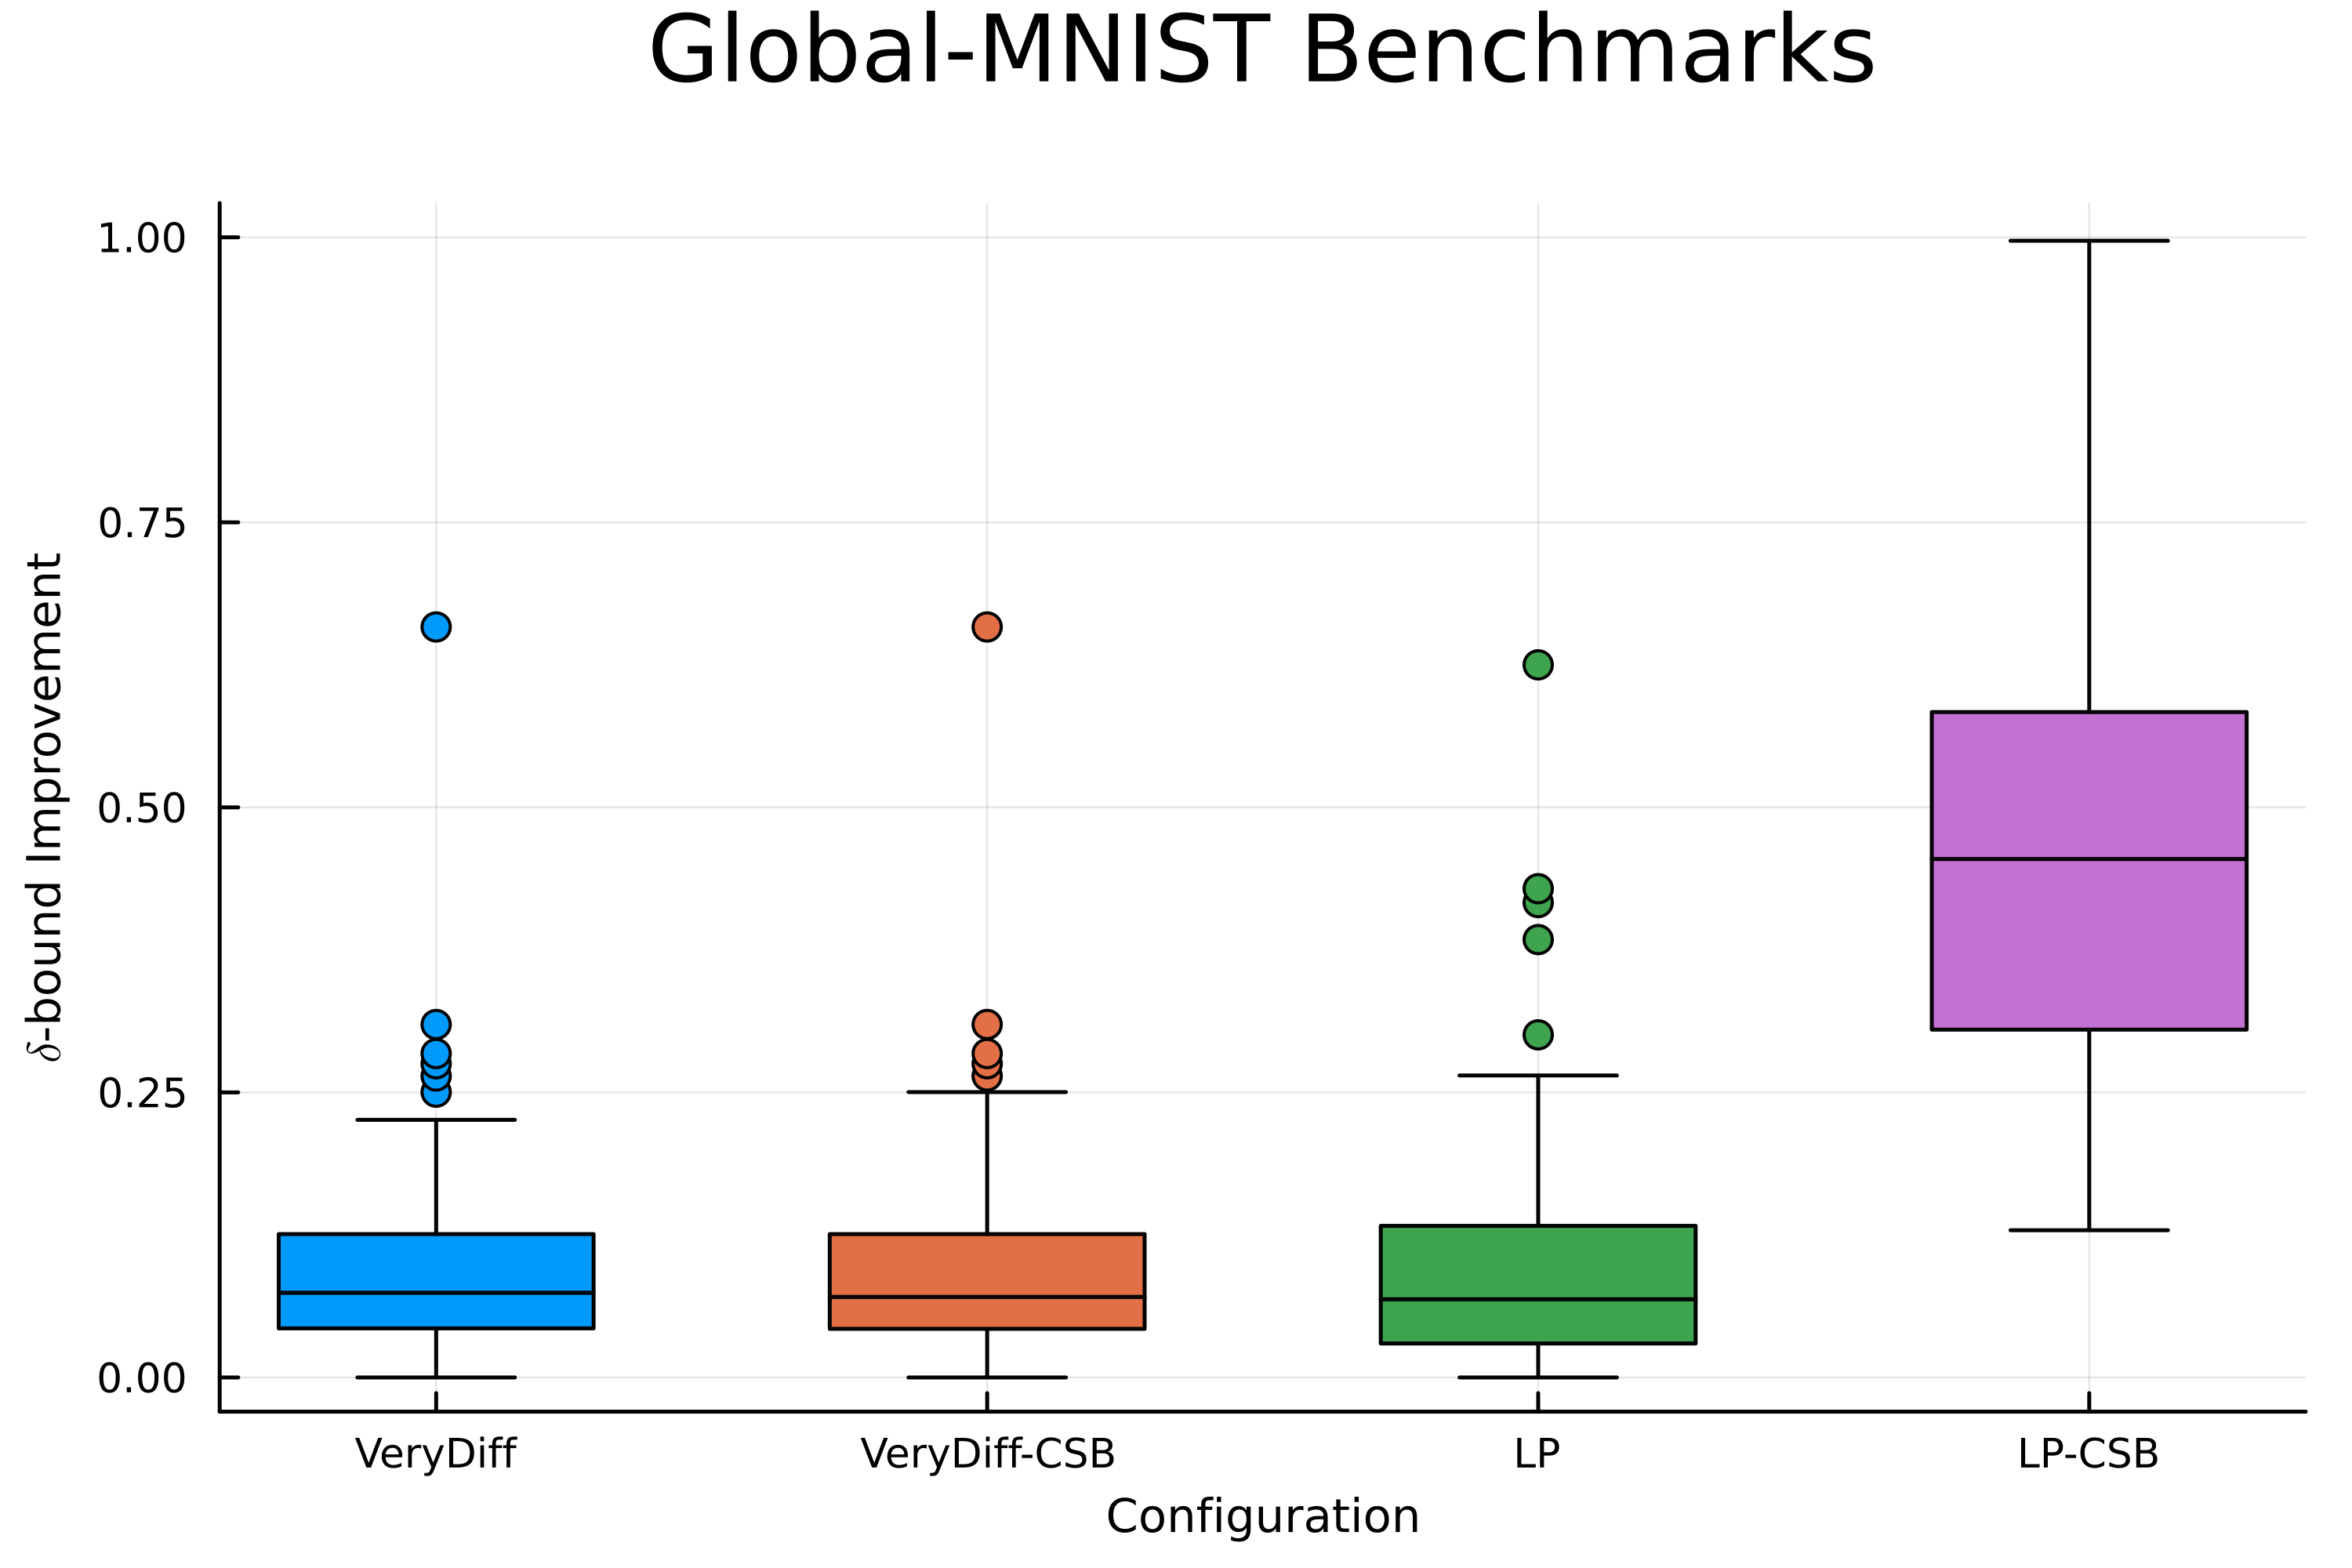

In [56]:
p = plot(dpi=500, widen=true, legend=false)
plot!(plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(guidefontsize=8, tickfontsize=7, xrotation=0)

xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")
ylims!(0, 1)

n = 4

common_unknown = mapfoldl(config -> config.df.status .== "UNKNOWN", .&, eachrow(mnist_dfs))
δ_bounds = mapreduce(config -> sort(config.df[common_unknown, :δ_bound]), hcat, eachrow(mnist_dfs[1:n, :]))
@df mnist_dfs[1:n, :] boxplot!(hcat(map(c -> configs_names[c], :config)...), δ_bounds, subplot=1)

# boxplot!(["  "], [0], lc=:transparent)
# boxplot!(["      "], [0], lc=:transparent)

savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-boxplot.pdf"))
savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-boxplot.png"))

p

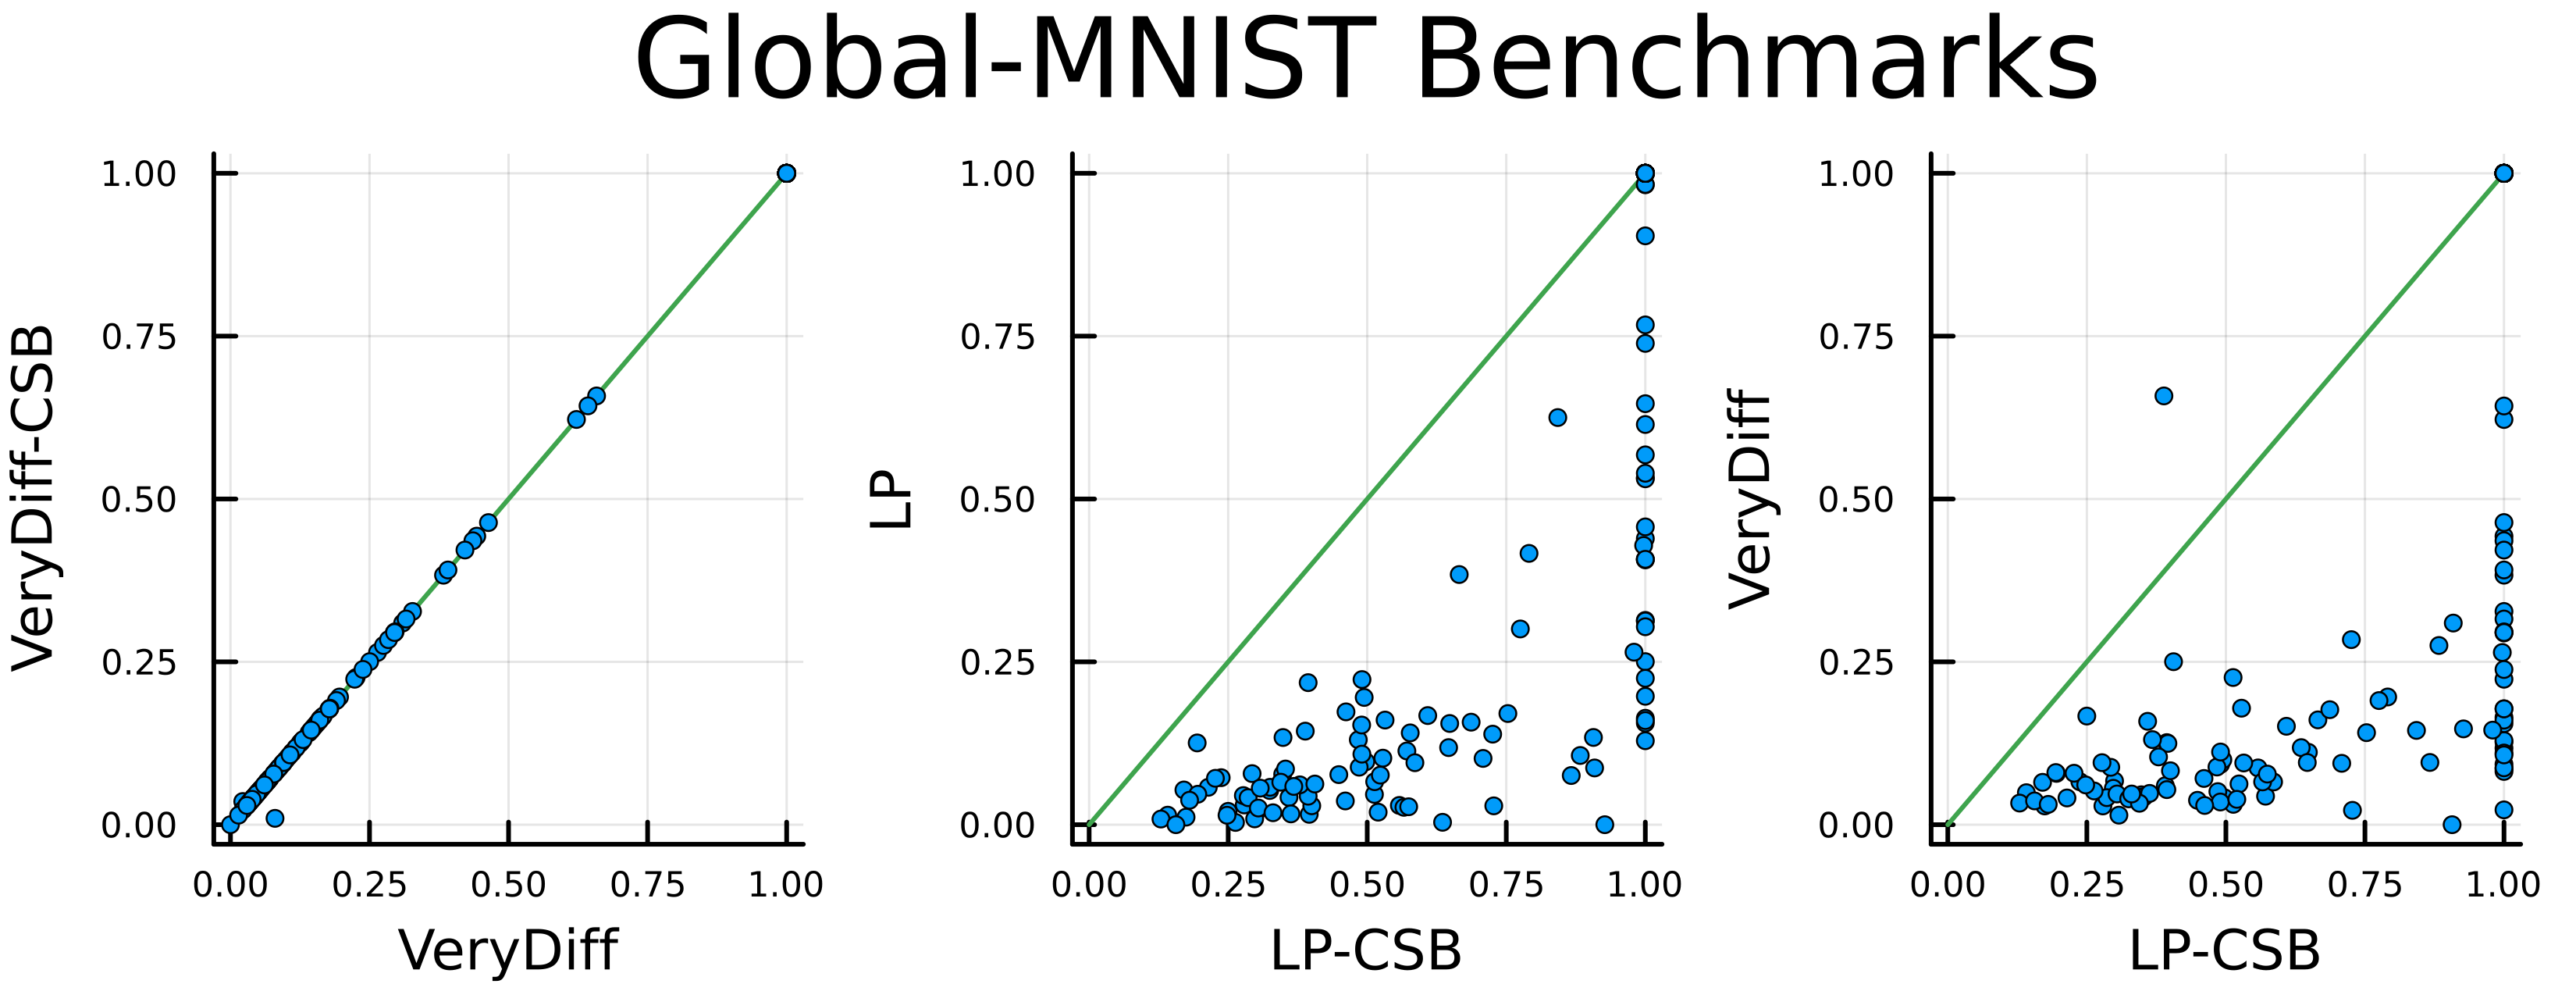

In [68]:
p = plot(dpi=600, widen=true, legend=false; layout=grid(1, 3), size=(550, 210))

plot!(plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(guidefontsize=8, tickfontsize=5, legendfontsize=3)

xlims!(0, 1)
ylims!(0, 1)

# combinations = [(2, 1), (3, 1), (3, 4), (6, 5), (7, 5), (8, 5), (3, 5), (4, 5), (2, 5)]
combinations = [(1, 2), (4, 3), (4, 1)]

for (n, (i, j)) in enumerate(combinations)
    df₁, df₂ = mnist_dfs[i, :], mnist_dfs[j, :]

    xlabel!(configs_names[df₁.config], subplot=n)
    ylabel!(configs_names[df₂.config], subplot=n)

    scatter!(df₁.df.δ_bound, df₂.df.δ_bound, markersize=2.0, subplot=n)
    plot!(range(0, 1), range(0, 1), z_order=1, c=3, subplot=n)
end

savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-bounds.pdf"))
savefig(p, joinpath(eval_mnist_dir, "split_diff_bounds", "$mnist_name-bounds.png"))

p

In [ ]:
acas_data = Dict(c => CSV.read(acas_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

In [ ]:
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=2)
max_y = 0
for (i, (name, configs)) in enumerate(all_configs)
    df = DataFrame()
    temp = DataFrame()
    for config in configs
        temp = transform(acas_data[config], :status => "group")
        temp = combine(groupby(temp, :group), nrow => :count)
        temp = temp[.!(contains.(temp.group, "UNKNOWN")), :]
        temp[!, "config"] .= config
        df = vcat(df, temp)
    end
    names = map(c -> cfgs_names[c], df.config)
    max_y = max(max_y, maximum(df.count))
    groupedbar!(names, df.count, group=df.group, bar_position=:dodge, title=name, subplot=i)
end
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
plot!(p, legend=:best, legendcolumns=2, subplot=1)
plot!(p, ylims=(0, max_y+10))

savefig(p, "$eval_acas_dir/$(acas_name)-hist.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 100), ylims=(0, 120), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=2)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    runtimes = map(c -> c.runtime / 1e9, filter.(c -> c.status != "UNKNOWN", map(c -> acas_data[c], cfgs)))
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=1, legend=:topleft)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name).pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
num_cfgs = size(all_cfgs, 1)
p = boxplot(dpi=500, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=num_cfgs)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    unsolved_mask = mapfoldl(c -> acas_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfg][:, :]), 0.05)), hcat, cfgs)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
boxplot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-boxplot.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 3), size=(500, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
combinations = [(2, 1), (3, 2), (6, 2), (2, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[i]]), 0.05)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[j]]), 0.05)

        scatter!(p, y₁, y₂, markersize=2.0, label=labels[k], c=k, subplot=n)
    end
end

scatter!(p, subplot=7, label=labels, legend=:bottomright)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5, ytickfontsize=5, legendfontsize=3)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-bounds.pdf")

p